## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Data Loading

In [13]:
df = pd.read_csv("../Data/V-Dem-CD-v16.csv", low_memory=False)
df.head()

,country_name,country_text_id,country_id,year,historical_date,project,historical,histname,codingstart,codingend,...,v2edtefire_sd,v2edtefire_osp,v2edtefire_osp_codelow,v2edtefire_osp_codehigh,v2edtefire_osp_sd,v2edtefire_ord,v2edtefire_ord_codelow,v2edtefire_ord_codehigh,v2edtefire_mean,v2edtefire_nr
0,Mexico,MEX,3,1789,1789-01-01,1,1,Viceroyalty of New Spain,1789,2025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Mexico,MEX,3,1789,1789-10-17,1,1,Viceroyalty of New Spain,1789,2025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Mexico,MEX,3,1789,1789-12-31,1,1,Viceroyalty of New Spain,1789,2025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Mexico,MEX,3,1790,1790-01-01,1,1,Viceroyalty of New Spain,1789,2025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Mexico,MEX,3,1790,1790-12-31,1,1,Viceroyalty of New Spain,1789,2025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
list(df.columns)[:30]

['country_name',
 'country_text_id',
 'country_id',
 'year',
 'historical_date',
 'project',
 'historical',
 'histname',
 'codingstart',
 'codingend',
 'codingstart_contemp',
 'codingend_contemp',
 'codingstart_hist',
 'codingend_hist',
 'gapstart1',
 'gapstart2',
 'gapstart3',
 'gapend1',
 'gapend2',
 'gapend3',
 'gap_index',
 'COWcode',
 'v2x_polyarchy',
 'v2x_polyarchy_codelow',
 'v2x_polyarchy_codehigh',
 'v2x_polyarchy_sd',
 'v2x_libdem',
 'v2x_libdem_codelow',
 'v2x_libdem_codehigh',
 'v2x_libdem_sd']

## Data Processing

In [15]:
# extract only the relevant columns
df_f = df[
    [
        "country_name",
        "country_text_id",
        "year",
        "historical_date",
        "codingstart",
        "codingend",
        "v2x_polyarchy",
        "v2x_libdem",
        "v2x_partipdem",
        "v2x_delibdem",
        "v2x_egaldem",
    ]
]

In [16]:
# extract only the relevant countries (Hungary in this case)
df_h = df_f[df_f["country_name"] == "Hungary"]

In [17]:
df_h.head()

,country_name,country_text_id,year,historical_date,codingstart,codingend,v2x_polyarchy,v2x_libdem,v2x_partipdem,v2x_delibdem,v2x_egaldem
74381,Hungary,HUN,1789,1789-01-01,1789,2025,NaN,NaN,NaN,NaN,NaN
74382,Hungary,HUN,1789,1789-12-31,1789,2025,0.057,0.069,0.091,NaN,NaN
74383,Hungary,HUN,1790,1790-01-01,1789,2025,0.057,0.069,0.091,NaN,NaN
74384,Hungary,HUN,1790,1790-11-12,1789,2025,0.057,0.069,0.091,NaN,NaN
74385,Hungary,HUN,1790,1790-12-31,1789,2025,0.057,0.069,0.091,NaN,NaN


In [35]:
df_h.loc[:, "historical_date"] = pd.to_datetime(
    df_h["historical_date"], format="%Y-%m-%d"
)

## Visualizations

In [26]:
plt.figure(figsize=(15, 8))

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

c:\Users\Kalami\anaconda3\envs\SKWeak\Lib\site-packages\pandas\core\indexes\base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


<Axes: xlabel='historical_date'>

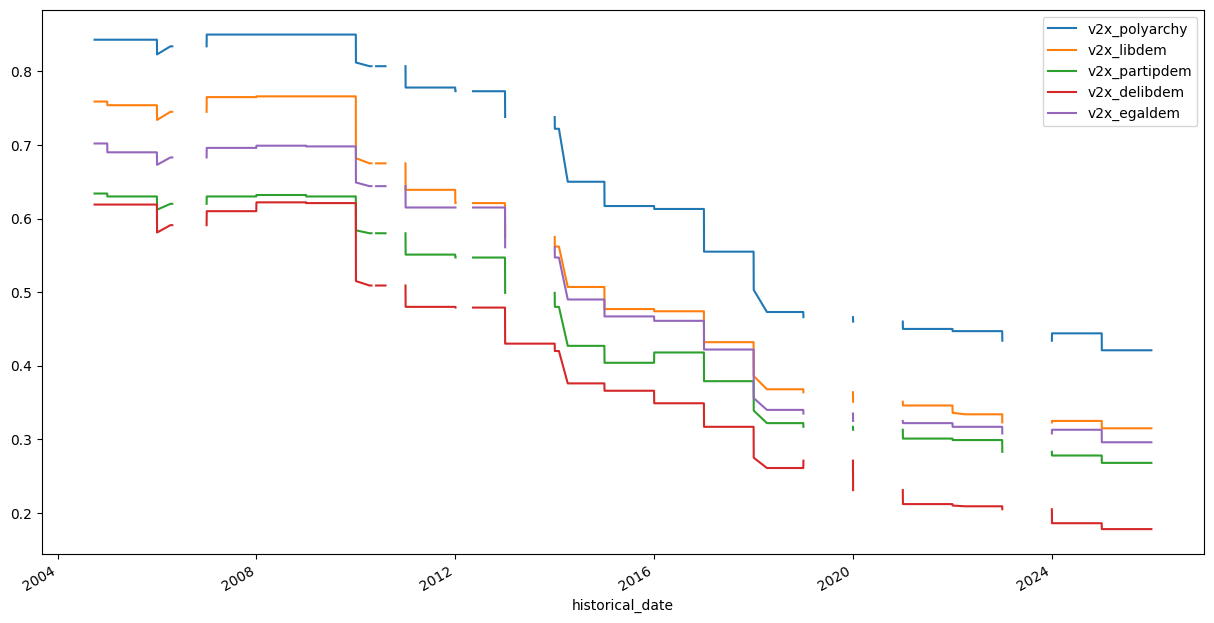

In [ ]:
df_hd = df_h.set_index("historical_date")

ax = df_hd[
    [
        "v2x_polyarchy",
        "v2x_libdem",
        "v2x_partipdem",
        "v2x_delibdem",
        "v2x_egaldem",
    ]
][(df_hd.index > "2004-01-01")].plot.line()

ax.figure.set_size_inches(15, 8)
ax

## Saving the data for later use

In [ ]:
df_h.to_csv("../Data/V-Dem-HU-v16.csv")